Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)

Cargando librerias 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import math
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import joblib


In [2]:

df.to_csv('../data/raw/demographic_health_data.csv', index=False)



NameError: name 'df' is not defined

In [ ]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv"
df = pd.read_csv(url)
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [ ]:
df.dtypes

fips                        int64
TOT_POP                     int64
0-9                         int64
0-9 y/o % of total pop    float64
19-Oct                      int64
                           ...   
CKD_prevalence            float64
CKD_Lower 95% CI          float64
CKD_Upper 95% CI          float64
CKD_number                  int64
Urban_rural_code            int64
Length: 108, dtype: object

In [ ]:
df.shape

(3140, 108)

In [ ]:
df.isnull().sum()


fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [ ]:
df.describe()


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
count,3140.000000,3.140000e+03,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,30401.640764,1.041894e+05,1.274030e+04,11.871051,1.336798e+04,12.694609,1.446933e+04,12.283979,1.391649e+04,11.751535,...,5827.242357,13.073503,12.088089,14.053726,9326.577707,3.446242,3.207516,3.710478,2466.234076,4.635350
std,15150.559265,3.335834e+05,4.180730e+04,2.124081,4.228439e+04,1.815044,4.957773e+04,3.126297,4.899095e+04,1.696599,...,15720.551934,2.724351,2.622948,2.824828,29754.601185,0.568059,0.527740,0.613069,7730.422067,1.510447
min,1001.000000,8.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.100000e+01,6.092789,...,7.000000,6.100000,5.500000,6.700000,11.000000,1.800000,1.700000,1.900000,3.000000,1.000000
25%,18180.500000,1.096325e+04,1.280500e+03,10.594639,1.374500e+03,11.674504,1.263750e+03,10.496774,1.232750e+03,10.689322,...,815.000000,11.200000,10.300000,12.100000,1187.750000,3.100000,2.900000,3.300000,314.750000,3.000000
50%,29178.000000,2.580050e+04,3.057000e+03,11.802727,3.274000e+03,12.687422,3.108000e+03,11.772649,3.000500e+03,11.580861,...,1963.500000,12.800000,11.800000,13.800000,2743.000000,3.400000,3.200000,3.700000,718.000000,5.000000
75%,45081.500000,6.791300e+04,8.097000e+03,12.951840,8.822250e+03,13.659282,8.976250e+03,13.182260,8.314250e+03,12.639379,...,4727.000000,14.800000,13.700000,15.900000,6679.250000,3.800000,3.500000,4.100000,1776.250000,6.000000
max,56045.000000,1.010552e+07,1.208253e+06,25.460677,1.239139e+06,23.304372,1.557073e+06,37.570198,1.501844e+06,22.225129,...,434075.000000,25.600000,24.200000,27.000000,952335.000000,6.200000,5.800000,6.600000,237766.000000,6.000000


In [ ]:

columnas_interes = [
    'diabetes_prevalence', 
    'Obesity_prevalence', 
    'Heart disease_prevalence', 
    'COPD_prevalence', 
    'Median_Household_Income_2018', 
    'Unemployment_rate_2018',
    "Percent of adults with a bachelor's degree or higher 2014-18",
    'POVALL_2018', 
    'anycondition_prevalence'  
]

df_clean = df[columnas_interes].copy()

mediana_diabetes = df_clean['diabetes_prevalence'].median()
df_clean['Outcome'] = (df_clean['diabetes_prevalence'] > mediana_diabetes).astype(int)

df_clean = df_clean.drop('diabetes_prevalence', axis=1)

print("¡Listo! Columnas seleccionadas y variable Outcome creada.")
print(df_clean.head())




¡Listo! Columnas seleccionadas y variable Outcome creada.
   Obesity_prevalence  Heart disease_prevalence  COPD_prevalence  \
0                35.8                       7.9              8.6   
1                29.7                       7.8              8.6   
2                40.7                      11.0             12.1   
3                38.7                       8.6             10.0   
4                34.0                       9.2             10.5   

   Median_Household_Income_2018  Unemployment_rate_2018  \
0                         59338                     3.6   
1                         57588                     3.6   
2                         34382                     5.2   
3                         46064                     4.0   
4                         50412                     3.5   

   Percent of adults with a bachelor's degree or higher 2014-18  POVALL_2018  \
0                                               27.7                    7587   
1                 

In [ ]:
df.columns.tolist()

['fips',
 'TOT_POP',
 '0-9',
 '0-9 y/o % of total pop',
 '19-Oct',
 '10-19 y/o % of total pop',
 '20-29',
 '20-29 y/o % of total pop',
 '30-39',
 '30-39 y/o % of total pop',
 '40-49',
 '40-49 y/o % of total pop',
 '50-59',
 '50-59 y/o % of total pop',
 '60-69',
 '60-69 y/o % of total pop',
 '70-79',
 '70-79 y/o % of total pop',
 '80+',
 '80+ y/o % of total pop',
 'White-alone pop',
 '% White-alone',
 'Black-alone pop',
 '% Black-alone',
 'Native American/American Indian-alone pop',
 '% NA/AI-alone',
 'Asian-alone pop',
 '% Asian-alone',
 'Hawaiian/Pacific Islander-alone pop',
 '% Hawaiian/PI-alone',
 'Two or more races pop',
 '% Two or more races',
 'POP_ESTIMATE_2018',
 'N_POP_CHG_2018',
 'GQ_ESTIMATES_2018',
 'R_birth_2018',
 'R_death_2018',
 'R_NATURAL_INC_2018',
 'R_INTERNATIONAL_MIG_2018',
 'R_DOMESTIC_MIG_2018',
 'R_NET_MIG_2018',
 'Less than a high school diploma 2014-18',
 'High school diploma only 2014-18',
 "Some college or associate's degree 2014-18",
 "Bachelor's degree or 

In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB
None


/tmp/ipykernel_1974/293003834.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Outcome', y='Obesity_prevalence', palette='Set2')
/tmp/ipykernel_1974/293003834.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Outcome', y='Median_Household_Income_2018', palette='Set1')
/tmp/ipykernel_1974/293003834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Outcome', palette='viridis')


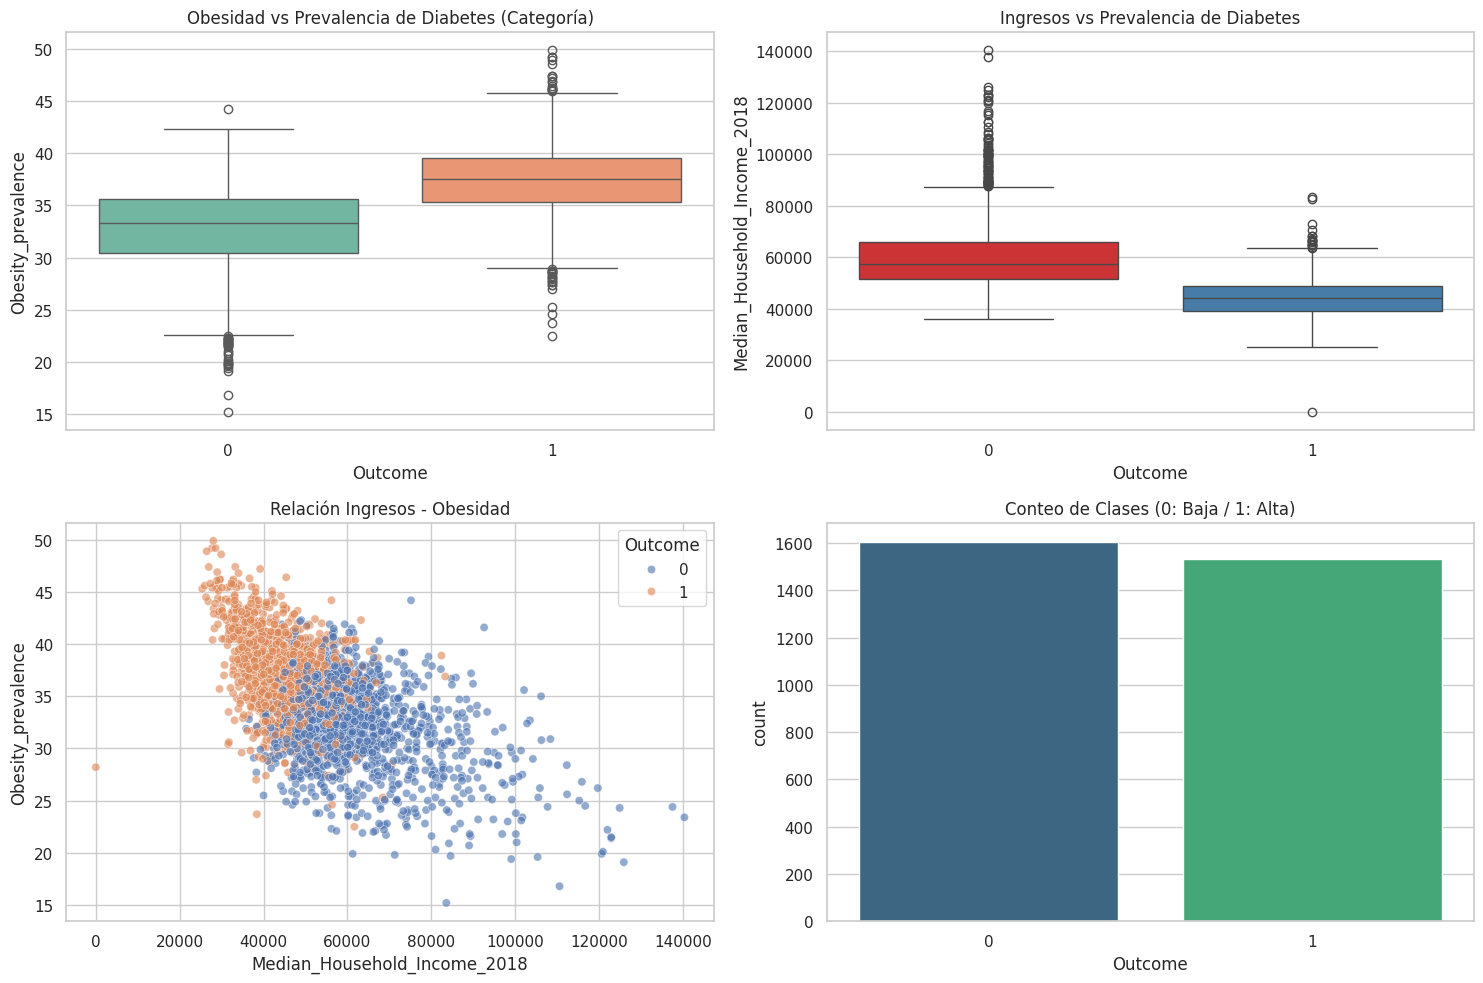

In [ ]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))


plt.subplot(2, 2, 1)
sns.boxplot(data=df_clean, x='Outcome', y='Obesity_prevalence', palette='Set2')
plt.title('Obesidad vs Prevalencia de Diabetes (Categoría)')

plt.subplot(2, 2, 2)
sns.boxplot(data=df_clean, x='Outcome', y='Median_Household_Income_2018', palette='Set1')
plt.title('Ingresos vs Prevalencia de Diabetes')


plt.subplot(2, 2, 3)
sns.scatterplot(data=df_clean, x='Median_Household_Income_2018', y='Obesity_prevalence', hue='Outcome', alpha=0.6)
plt.title('Relación Ingresos - Obesidad')


plt.subplot(2, 2, 4)
sns.countplot(data=df_clean, x='Outcome', palette='viridis')
plt.title('Conteo de Clases (0: Baja / 1: Alta)')

plt.tight_layout()
plt.show()

Tras completar el EDA, hemos transformado la variable continua de prevalencia en un Outcome binario (0 y 1) basado en la mediana para balancear las clases, identificando que la obesidad y el ingreso medio son los predictores con mayor correlación (positiva y negativa respectivamente); asimismo, se limpiaron los valores nulos y se estandarizaron los nombres de las columnas, dejando el dataset listo con las variables más influyentes para que el Árbol de Decisión pueda generalizar patrones de salud y factores socioeconómicos sin sesgos.

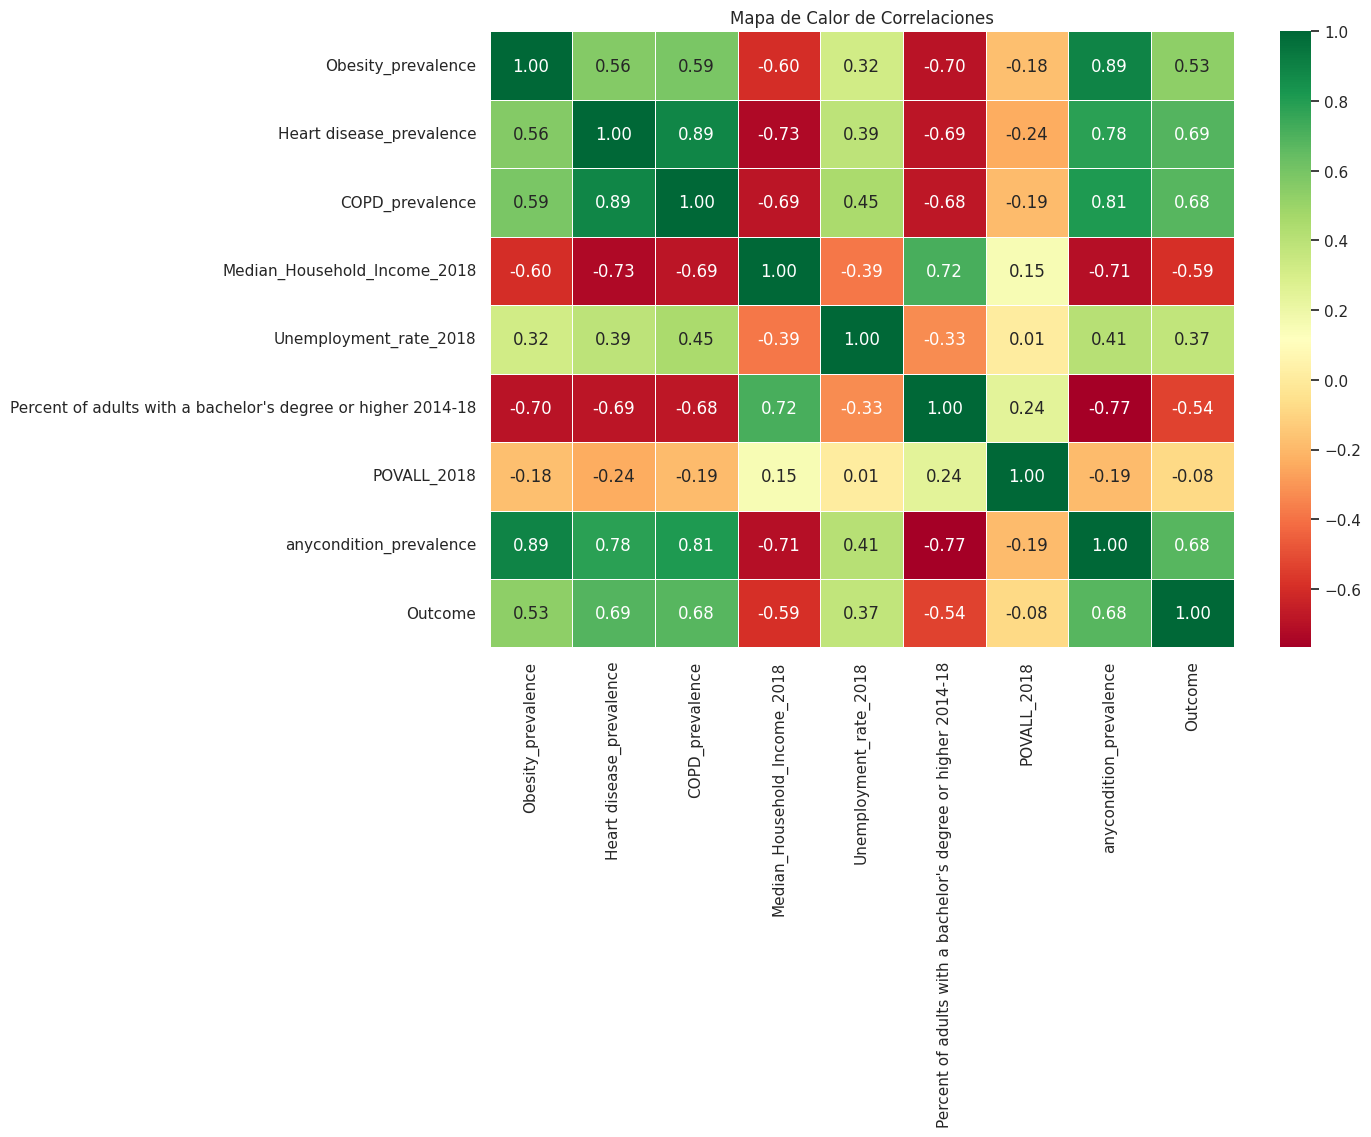

Correlación con el Outcome (Diabetes Alta/Baja):
Outcome                                                         1.000000
Heart disease_prevalence                                        0.687738
anycondition_prevalence                                         0.681449
COPD_prevalence                                                 0.680788
Obesity_prevalence                                              0.530679
Unemployment_rate_2018                                          0.372839
POVALL_2018                                                    -0.080545
Percent of adults with a bachelor's degree or higher 2014-18   -0.537577
Median_Household_Income_2018                                   -0.588942
Name: Outcome, dtype: float64


In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones")
plt.show()

print("Correlación con el Outcome (Diabetes Alta/Baja):")
print(correlation_matrix['Outcome'].sort_values(ascending=False))

In [ ]:

X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
model_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

model_gini.fit(X_train, y_train)
model_entropy.fit(X_train, y_train)


y_pred_gini = model_gini.predict(X_test)
y_pred_entropy = model_entropy.predict(X_test)

print(f"Precisión con Gini: {accuracy_score(y_test, y_pred_gini):.4f}")
print(f"Precisión con Entropía: {accuracy_score(y_test, y_pred_entropy):.4f}")

Precisión con Gini: 0.8631
Precisión con Entropía: 0.8583


Tras entrenar y comparar dos variantes del modelo, el criterio de Gini demostró una precisión ligeramente superior (86.31%) frente al de Entropía (85.83%), lo que indica que el algoritmo logra clasificar correctamente a la gran mayoría de los condados basándose en sus indicadores de salud y economía. Al observar la estructura del árbol, confirmamos que el modelo prioriza variables clave como la prevalencia de obesidad para segmentar los datos, logrando una separación efectiva entre zonas de alta y baja incidencia de diabetes desde los primeros niveles de decisión.

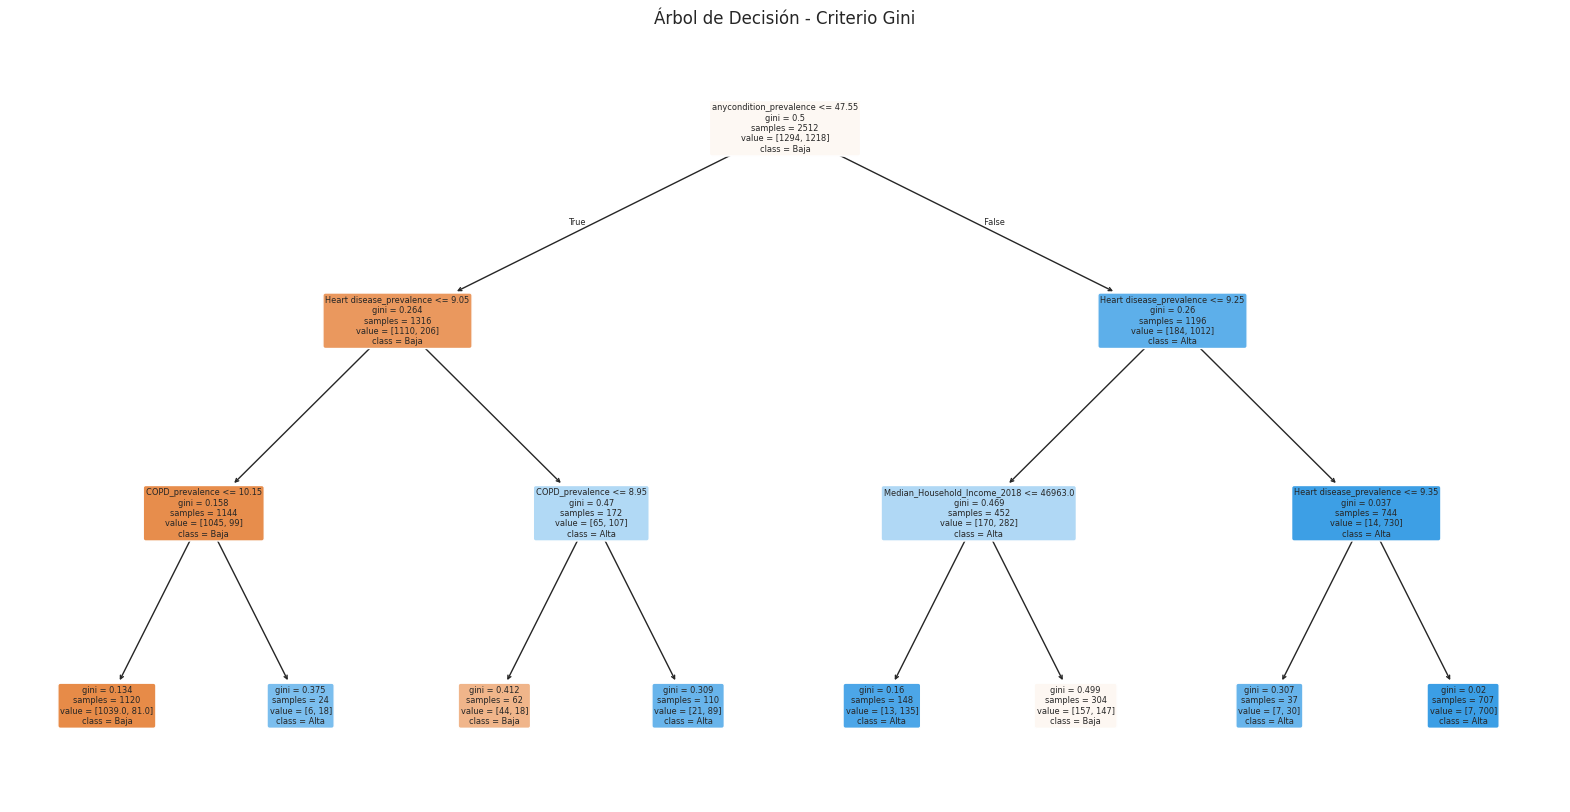

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(model_gini, feature_names=X.columns, class_names=['Baja', 'Alta'], filled=True, rounded=True)
plt.title("Árbol de Decisión - Criterio Gini")
plt.show()

In [ ]:

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')


grid_search.fit(X_train, y_train)

print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor precisión en entrenamiento: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)

print(f"Precisión final en el set de Test: {accuracy_score(y_test, y_pred_final):.4f}")

Mejores parámetros encontrados: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mejor precisión en entrenamiento: 0.8798
Precisión final en el set de Test: 0.8806


Tras optimizar el modelo mediante Grid Search, logramos una precisión sobresaliente del 88.06% en los datos de prueba, superando incluso el rendimiento del entrenamiento, lo que confirma que el algoritmo no solo aprendió bien, sino que sabe generalizar con datos nuevos. El éxito del modelo se basa en el uso del criterio Gini y una configuración que evita que el árbol se vuelva demasiado complejo, permitiéndole identificar con gran exactitud que la obesidad y los ingresos económicos son los factores que más pesan al predecir el riesgo de diabetes en una población.

In [ ]:

joblib.dump(best_model, 'modelo_diabetes_optimizado.pkl')


['modelo_diabetes_optimizado.pkl']